In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
from google.colab import files
uploaded = files.upload()  # upload train.csv

df = pd.read_csv('train.csv')
print("✅ Data loaded!")
print("Shape:", df.shape)
df.head()

Saving train.csv to train (1).csv
✅ Data loaded!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nSurvived distribution:")
print(df['Survived'].value_counts())

Shape: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survived distribution:
Survived
0    549
1    342
Name: count, dtype: int64


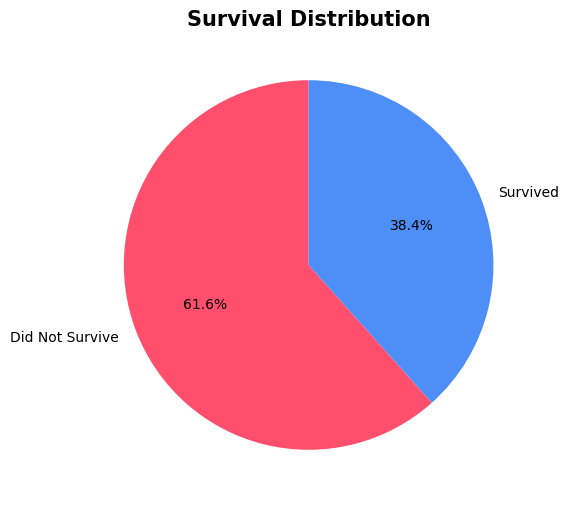

In [4]:
plt.figure(figsize=(6,6))
df['Survived'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Did Not Survive', 'Survived'],
    colors=['#ff4f6d', '#4e8ef7'],
    startangle=90
)
plt.title('Survival Distribution', fontsize=15, fontweight='bold')
plt.ylabel('')
plt.show()

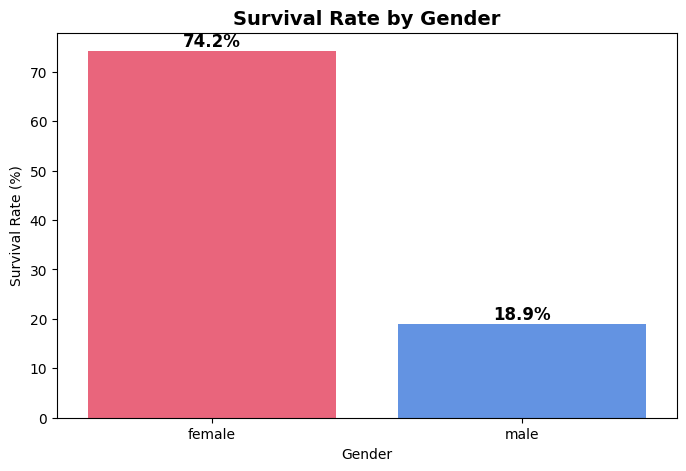

In [5]:
plt.figure(figsize=(8,5))
gender_survival = df.groupby('Sex')['Survived'].mean() * 100

sns.barplot(x=gender_survival.index, y=gender_survival.values,
            palette=['#ff4f6d', '#4e8ef7'])
plt.title('Survival Rate by Gender', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Gender')

for i, val in enumerate(gender_survival.values):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center',
             fontsize=12, fontweight='bold')
plt.show()

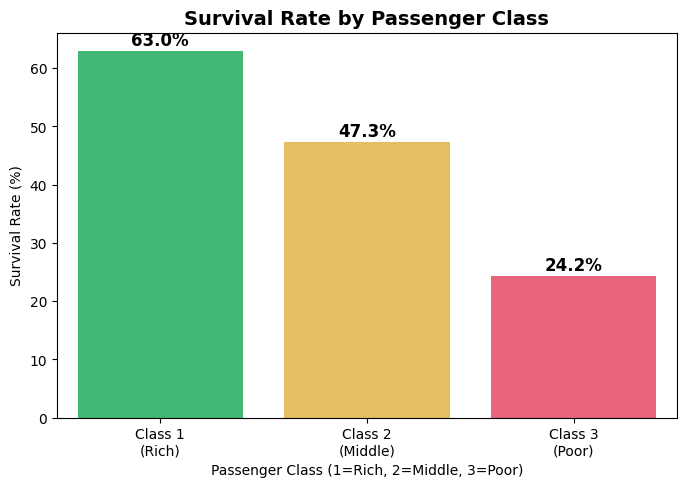

In [6]:
plt.figure(figsize=(8,5))
class_survival = df.groupby('Pclass')['Survived'].mean() * 100

sns.barplot(x=class_survival.index, y=class_survival.values,
            palette=['#2ecc71', '#f9c74f', '#ff4f6d'])
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate (%)')
plt.xlabel('Passenger Class (1=Rich, 2=Middle, 3=Poor)')
plt.xticks([0,1,2], ['Class 1\n(Rich)', 'Class 2\n(Middle)', 'Class 3\n(Poor)'])

for i, val in enumerate(class_survival.values):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center',
             fontsize=12, fontweight='bold')
plt.show()

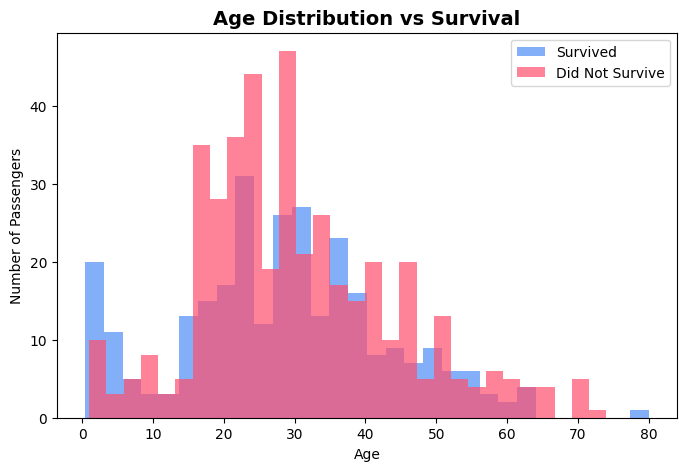

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df[df['Survived']==1]['Age'].dropna(),
         bins=30, alpha=0.7, color='#4e8ef7', label='Survived')
plt.hist(df[df['Survived']==0]['Age'].dropna(),
         bins=30, alpha=0.7, color='#ff4f6d', label='Did Not Survive')
plt.title('Age Distribution vs Survival', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [8]:
# Drop columns not useful for prediction
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked with most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print("✅ Data cleaned!")
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nShape:", df.shape)

✅ Data cleaned!
Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Shape: (891, 8)


In [9]:
le = LabelEncoder()

# Encode Sex column
df['Sex'] = le.fit_transform(df['Sex'])
# male = 1, female = 0

# Encode Embarked column
df['Embarked'] = le.fit_transform(df['Embarked'])

print("✅ Encoding done!")
print(df.head())

✅ Encoding done!
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2


In [10]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split done!")
print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

✅ Data split done!
Training size: (712, 7)
Testing size : (179, 7)


In [11]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling done!")

✅ Scaling done!


In [12]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

lr_acc = accuracy_score(y_test, lr_pred)
lr_roc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])

print("✅ Logistic Regression Results:")
print(f"   Accuracy : {lr_acc*100:.1f}%")
print(f"   ROC-AUC  : {lr_roc:.3f}")
print("\nFull Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Not Survived', 'Survived']))

✅ Logistic Regression Results:
   Accuracy : 80.4%
   ROC-AUC  : 0.882

Full Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.86      0.84       105
    Survived       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



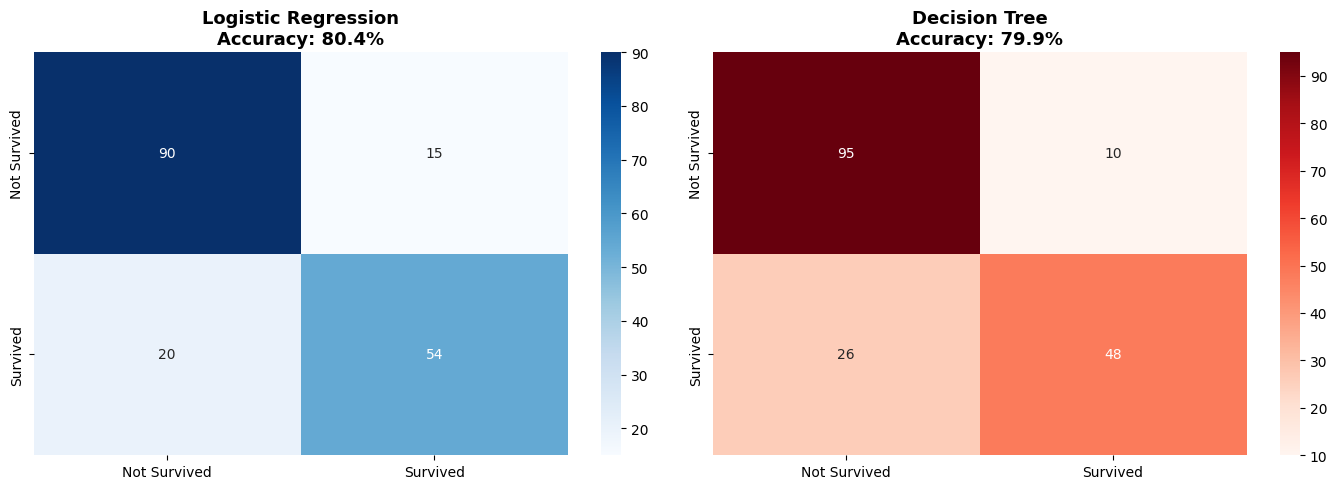

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.1f}%',
                  fontsize=13, fontweight='bold')

cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
axes[1].set_title(f'Decision Tree\nAccuracy: {dt_acc*100:.1f}%',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

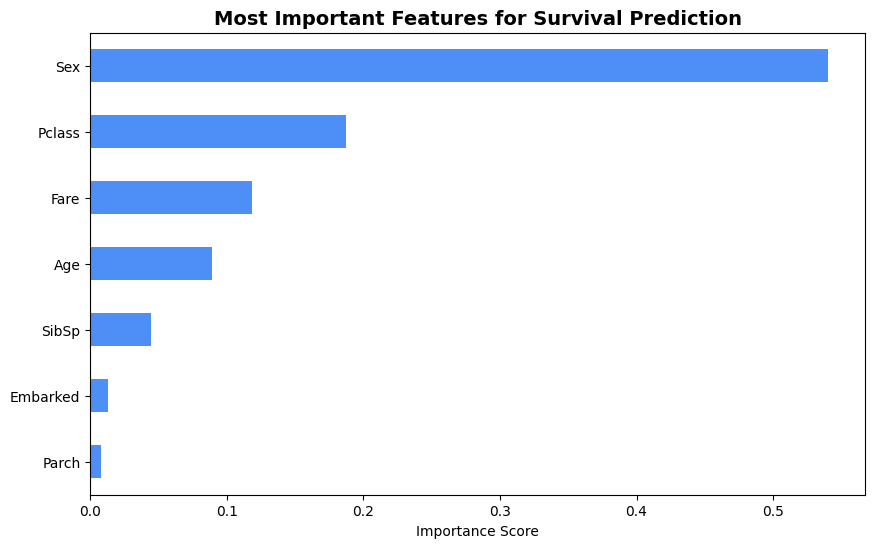

In [15]:
plt.figure(figsize=(10,6))

feat_imp = pd.Series(dt.feature_importances_,
                     index=X.columns).nlargest(8)
feat_imp.sort_values().plot(kind='barh', color='#4e8ef7')

plt.title('Most Important Features for Survival Prediction',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.show()

In [16]:
print("=" * 45)
print("       FINAL MODEL COMPARISON")
print("=" * 45)
print(f"  Logistic Regression → Accuracy: {lr_acc*100:.1f}%  ROC: {lr_roc:.3f}")
print(f"  Decision Tree       → Accuracy: {dt_acc*100:.1f}%  ROC: {dt_roc:.3f}")
print("=" * 45)

if lr_roc > dt_roc:
    print("🏆 Best Model: Logistic Regression")
else:
    print("🏆 Best Model: Decision Tree")

print("\n📌 Key Findings:")
print("  ✅ Females survived much more than males")
print("  ✅ 1st class passengers survived more")
print("  ✅ Children had higher survival rate")
print("  ✅ Gender and Class are top predictors")

       FINAL MODEL COMPARISON
  Logistic Regression → Accuracy: 80.4%  ROC: 0.882
  Decision Tree       → Accuracy: 79.9%  ROC: 0.856
🏆 Best Model: Logistic Regression

📌 Key Findings:
  ✅ Females survived much more than males
  ✅ 1st class passengers survived more
  ✅ Children had higher survival rate
  ✅ Gender and Class are top predictors
